In [6]:

import numpy as np
from generate_price_data import *
import pandas as pd
from constructing_models import *
from itertools import product

### Loading data

We first load data from the specified folder and construct them in a common matrix.

In [7]:
datadir = Path.cwd() / "data"
print(datadir)

EARLIEST_DATE = pd.Timestamp("2000-01-01")
MIN_ROW_COUNT = 4000

common_idx = None
c = 0
assets_filter = []
for sector in datadir.iterdir():
    for asset in sector.iterdir():
        df = pd.read_csv(datadir / asset, index_col=0)
        df.index = pd.to_datetime(df.index)
        df = df[df.index >= EARLIEST_DATE]
        if len(df) < MIN_ROW_COUNT:
            assets_filter.append(asset.name)
            continue
        common_idx = common_idx.intersection(df.index) if common_idx is not None else df.index
        c += 1

data = np.empty((len(common_idx), c))

c = 0
for sector in datadir.iterdir():
    for asset in sector.iterdir():
        if asset.name in assets_filter:
            continue
        df = pd.read_csv(datadir / asset, index_col=0)
        df.index = pd.to_datetime(df.index)
        df = df[df.index.isin(common_idx)]
        data[:, c] = df["Close"].pct_change()
        c += 1

data = data[1:, :]


c:\Projects\Qlearning_finance\data


In [8]:
print(data)
print('shape:'); print(data.shape)

[[ 0.04980986 -0.00598007  0.05203007 ...  0.00178197  0.00907024
   0.00559432]
 [-0.01581569  0.00267392 -0.00936669 ...  0.00612661  0.00876432
   0.00404733]
 [-0.0120521  -0.016      -0.02042377 ...  0.00275008  0.00022273
  -0.00050424]
 ...
 [-0.00032052  0.00433569  0.00755007 ... -0.00060454  0.00524427
  -0.00083203]
 [ 0.00833601 -0.02436019 -0.01068043 ... -0.00205684  0.00192201
   0.00166544]
 [-0.02957076 -0.00158025 -0.00957686 ...  0.00872931  0.00593771
  -0.00083134]]
shape:
(4041, 198)


We again train multiple models (but now on real data!), like in the case with synthetic data.

In [13]:
num_actions = 10
A = np.random.dirichlet(np.full(data.shape[1], 1), num_actions)
rb_capacity = [2000]
rb_sample_size = [32]
gamma = [0.95]
t_replay_buffer = [100]
training_lookback_period = [15]
model_constructors = [construct_dqn_1, construct_dqn_2, construct_dqn_3]
target_update_freq = [500]
action_space = [A]
state_space = [data]
eps_decays = [0.997]

product_args = list(product(state_space, rb_capacity,
                            rb_sample_size, action_space, gamma, target_update_freq,
                            training_lookback_period, t_replay_buffer, model_constructors,
                            eps_decays))
for i, args in enumerate(product_args):
    ss, rbcap, rbss, asp, gam, targup, traininglookback, t_replay, mc, epsc = args
    model_constr_name = model_constructors.index(mc)
    model = Model2(
        ss, rbcap, rbss, asp, gam, targup, traininglookback, t_replay, mc, epsc, model_constr_name
        )
    model.train()
    print('Model trained')
    model.save(Path.cwd() / "producedModels" / "realDataModels", f"model_{i}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━

Instantiate all deployers with the different models, test them on the testing part of the data and plot the results.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

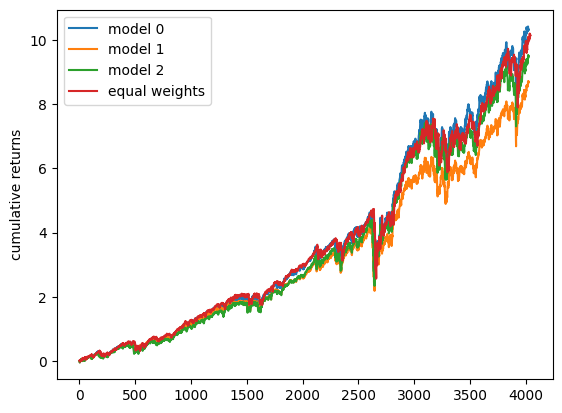

In [14]:
deployers = [
    ModelDeployer(
    modelpath=Path.cwd() / "producedModels" / "realDataModels" / f"model_{i}.keras",
    data=data,
    action_space=A
    )
    for i in range(3)
]
table = np.empty((len(deployers), 3))

fig, ax = plt.subplots()

for i, d in enumerate(deployers):
    (
        returns,
        cum_return,
        returns_vola_ann,
        sharpe,
        sortino,
        returns_equal_weights,
        returns_equal_weights_cum
    ) = d.run()
    table[i, :] = [np.mean(returns), sharpe, sortino]
    ax.plot(cum_return, label=f"model {i}")

table = pd.DataFrame(table, index=[f"model {i}" for i in range(3)], columns=["mean return", "sharpe", "sortino"])

ax.plot(returns_equal_weights_cum, label="equal weights")
ax.legend()
ax.set_ylabel("cumulative returns")
plt.show()

Add the equal weights row to the table and print it for comparison

In [15]:
table.loc['equal_weights'] = [
    np.mean(returns_equal_weights),
    np.mean(returns_equal_weights) * np.sqrt(255) / np.std(returns_equal_weights),
    np.mean(returns_equal_weights) * np.sqrt(255) / np.std(returns_equal_weights[returns_equal_weights < 0])
]
print(table)


               mean return    sharpe   sortino
model 0           0.000668  0.937800  1.145442
model 1           0.000626  0.900450  1.109800
model 2           0.000646  0.926626  1.147853
equal_weights     0.000657  0.955074  1.171474
